# Phân tích ...

## 0. Phát biểu bài toán

Mục tiêu: phân tích dữ liệu văn bản để đánh giá khả năng dự đoán thái độ (sentiment) của bài viết.

- Biến mục tiêu (Y): sentiment (-1, 0, 1)
- Biến đầu vào (X): text, keyword, độ dài bài viết,...

→ Bài toán: Classification

## Câu hỏi:
- Có thể dự đoán sentiment từ nội dung bài viết không?
- Dữ liệu có đủ chất lượng không?

## 1. Thu thập dữ liệu (Data Crawling)

- Nguồn: CafeF (https://cafef.vn), Vietstock (https://vietstock.vn)
- Phương pháp: web scraping
- Số mẫu: 2721
- Số biến: 6 (URL, Tiêu đề, Nội dung, Từ khóa, Chuyên mục, Nguồn)

### 1.1 Tải và import thư viện

In [115]:
!pip install underthesea

In [116]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 1.2 Load dữ liệu

In [117]:
from google.colab import files
uploaded = files.upload()

Saving raw_data.csv to raw_data.csv


In [118]:
economy_raw = pd.read_csv("raw_data.csv")
economy_raw.head()

,URL,Tiêu đề,Nội dung,Từ khóa,Chuyên mục,Nguồn
0,https://cafef.vn/tu-doanh-ctck-mua-rong-hon-70...,Tự doanh CTCK mua ròng hơn 700 tỷ đồng phiên 1...,"Thị trường tiếp tục phục hồi trong phiên 18/3,...","tự doanh ctck,, cổ phiếu,, đầu tư,, chứng khoá...",Chứng khoán,CafeF
1,https://cafef.vn/vu-an-xay-ra-tai-acv-va-cac-d...,Vụ án xảy ra tại ACV và các đơn vị liên quan v...,"Ngày 18/3, Tổng Bí thư Tô Lâm chủ trì cuộc họp...","hàng không,, tham nhũng,, ACV",Chứng khoán,CafeF
2,https://cafef.vn/sap-bay-keu-goi-dau-tu-nguoi-...,"'Sập bẫy' kêu gọi đầu tư, người đàn ông ở Đà N...",Cơ quan CSĐT Công an TP Đà Nẵng cho biết vừa b...,"đầu tư,, lừa đảo",Chứng khoán,CafeF
3,https://cafef.vn/bo-me-mr-pips-rut-ca-tram-ty-...,"Bố mẹ Mr Pips rút cả trăm tỷ đồng, mua hàng tr...",Cơ quan Cảnh sát điều tra Công an TP Hà Nội vừ...,"Mr Pips,, đầu tư,, lừa đảo,, tiền ảo,, vàng",Chứng khoán,CafeF
4,https://cafef.vn/hai-cuu-cong-an-nhan-thu-lao-...,"Hai cựu công an nhận thù lao 2 tỷ đồng, lập 't...",Cơ quan CSĐT Công an Hà Nội vừa hoàn tất kết l...,"lừa đảo,, Mr Pips",Chứng khoán,CafeF


In [119]:
economy_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2721 entries, 0 to 2720
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   URL         2721 non-null   object
 1   Tiêu đề     2721 non-null   object
 2   Nội dung    2721 non-null   object
 3   Từ khóa     2663 non-null   object
 4   Chuyên mục  2721 non-null   object
 5   Nguồn       2721 non-null   object
dtypes: object(6)
memory usage: 127.7+ KB


### 1.3 Phân tích Dữ liệu (EDA)

/tmp/ipykernel_6175/913565211.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')


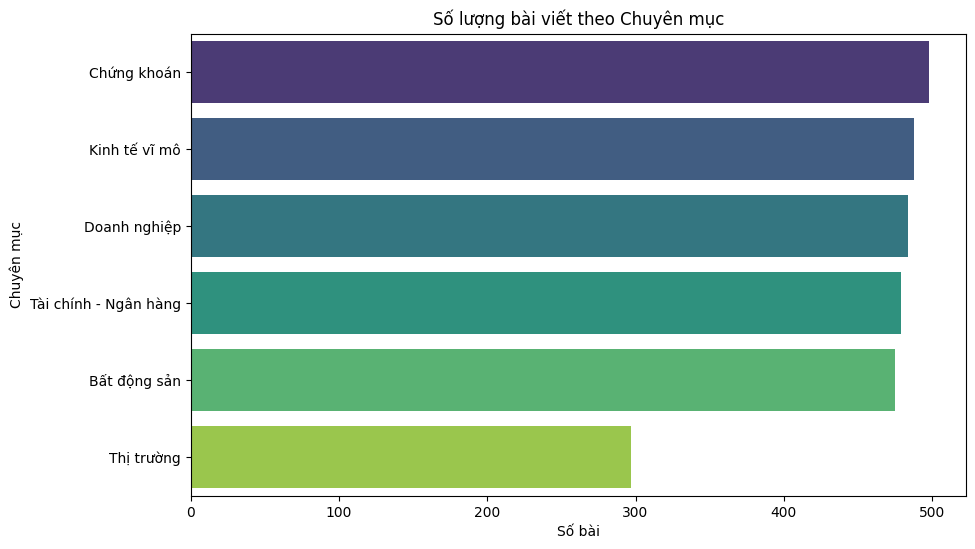


Thống kê Độ dài bài viết:
count    2721.000000
mean      794.586549
std       417.783988
min        45.000000
25%       508.000000
50%       716.000000
75%       988.000000
max      4656.000000
Name: Số lượng từ, dtype: float64


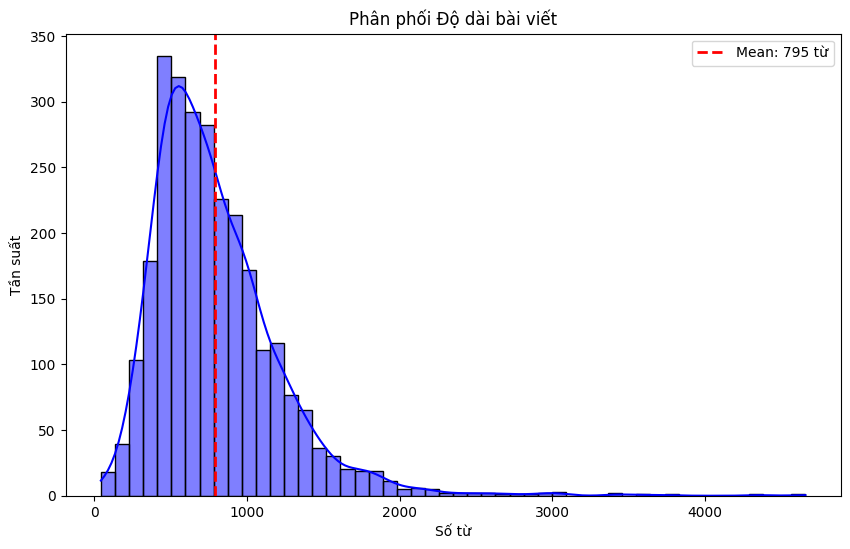


Số bài báo bị khuyết Từ khóa: 58 (2.13%)


In [120]:
# Thống kê theo Chuyên mục
cat_counts = economy_raw['Chuyên mục'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
plt.title('Số lượng bài viết theo Chuyên mục')
plt.xlabel('Số bài')
plt.ylabel('Chuyên mục')
plt.show()

# Độ dài bài viết (Số lượng từ)
economy_raw['Số lượng từ'] = (
    economy_raw['Tiêu đề'].fillna('').str.split().str.len() +
    economy_raw['Nội dung'].fillna('').str.split().str.len()
)

print("\nThống kê Độ dài bài viết:")
print(economy_raw['Số lượng từ'].describe())

plt.figure(figsize=(10,6))
sns.histplot(economy_raw['Số lượng từ'], bins=50, kde=True, color='blue')
plt.axvline(economy_raw['Số lượng từ'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {economy_raw['Số lượng từ'].mean():.0f} từ")
plt.title('Phân phối Độ dài bài viết')
plt.xlabel('Số từ')
plt.ylabel('Tần suất')
plt.legend()
plt.show()

# Tỷ lệ khuyết Từ khóa
missing_kw = economy_raw['Từ khóa'].isna().sum()
print(f"\nSố bài báo bị khuyết Từ khóa: {missing_kw} ({missing_kw/len(economy_raw)*100:.2f}%)")

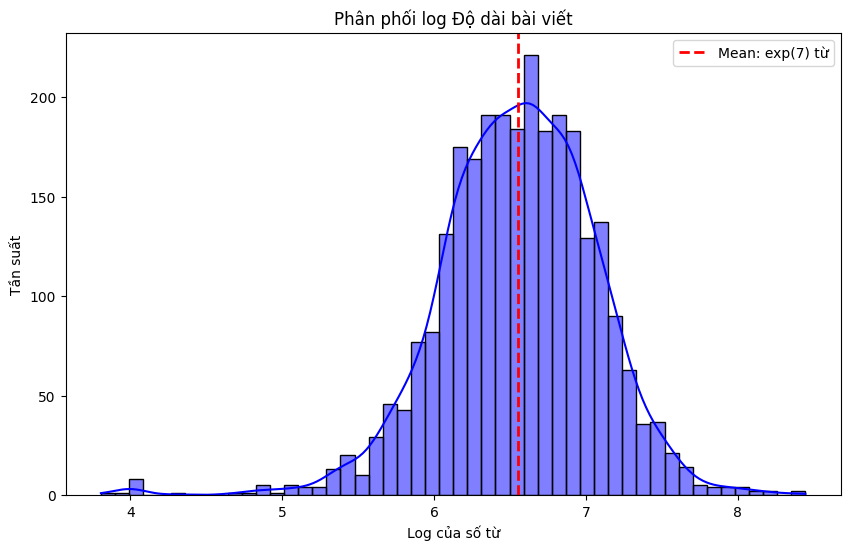

In [121]:
# Log của độ dài bài viết
plt.figure(figsize=(10,6))
sns.histplot(np.log(economy_raw['Số lượng từ']), bins=50, kde=True, color='blue')
plt.axvline(np.log(economy_raw['Số lượng từ']).mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: exp({np.log(economy_raw['Số lượng từ']).mean():.0f}) từ")
plt.title('Phân phối log Độ dài bài viết')
plt.xlabel('Log của số từ')
plt.ylabel('Tần suất')
plt.legend()
plt.show()

/tmp/ipykernel_6175/2238616738.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_keywords.values, y=top_keywords.index, palette='magma')


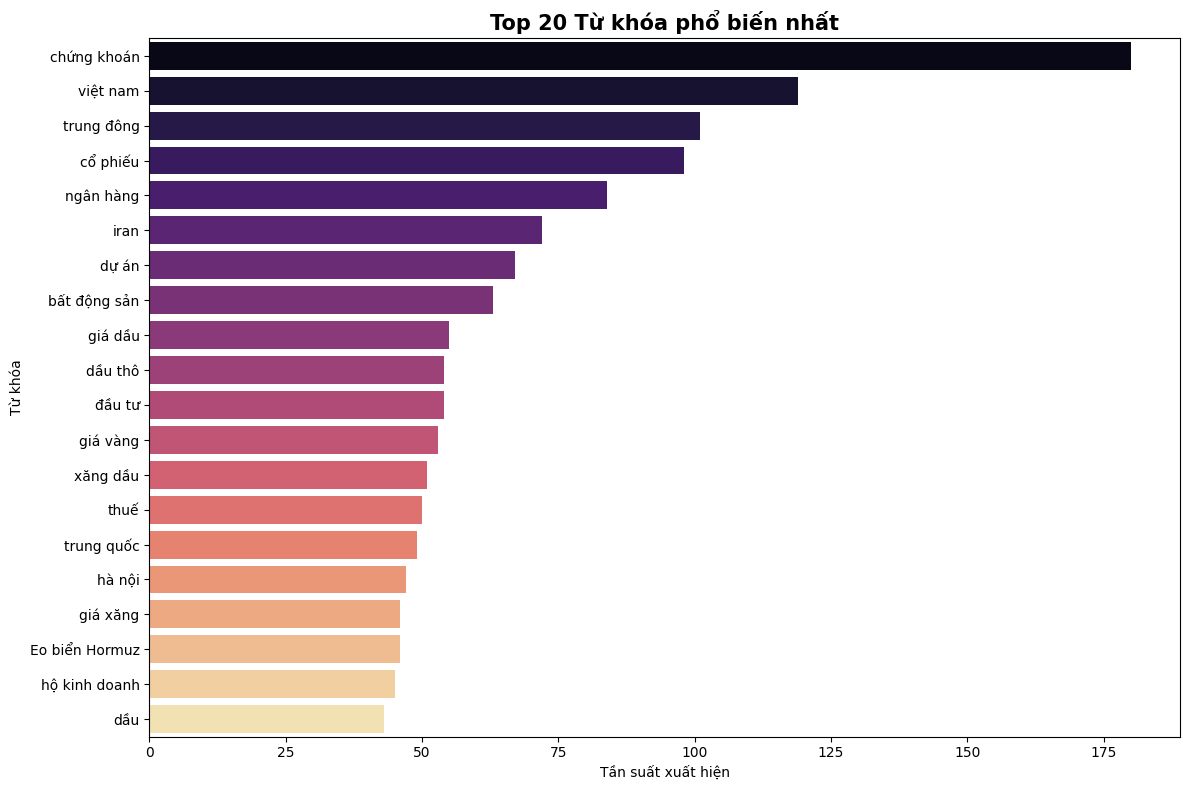

In [122]:
# Top 20 Từ khóa xuất hiện nhiều nhất
# Xử lý chuỗi từ khóa, tách bằng dấu phẩy và làm sạch khoảng trắng
keywords = economy_raw['Từ khóa'].dropna().astype(str).str.split(',').explode().str.strip()
keywords = keywords[keywords != ""] # Bỏ các tag rỗng
top_keywords = keywords.value_counts().head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_keywords.values, y=top_keywords.index, palette='magma')
plt.title('Top 20 Từ khóa phổ biến nhất', fontsize=15, fontweight='bold')
plt.xlabel('Tần suất xuất hiện')
plt.ylabel('Từ khóa')
plt.tight_layout()
plt.show()

## 2. Làm sạch và chuẩn hóa dữ liệu (data cleaning)
Các bước:
- Xử lý missing values
- Loại bỏ ký tự không cần thiết
- Chuẩn hoá text (lowercase)

### 2.1 Làm sạch dữ liệu

#### 2.1.1 Xóa các dòng bị thiếu ở cột "Từ khóa"

In [123]:
economy_clean = economy_raw.copy()
economy_clean.dropna(subset=["Từ khóa"], inplace=True)

#### 2.1.2 Ghép cột "Tiêu đề" và "Nội Dung"

In [124]:
economy_clean["text"] = economy_clean["Tiêu đề"].fillna('') + " " + economy_clean["Nội dung"].fillna('')

#### 2.1.3 Làm sạch cột text

In [125]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text).strip()

    return text

economy_clean["clean_text"] = economy_clean["text"].apply(clean_text)

#### 2.1.4 Lọc các bài viết không liên quan

##### 2.1.4.1 Phương pháp TF-IDF + Cosine similarity

In [126]:
seed_texts = [

"""
thị trường chứng khoán việt nam vn-index tăng giảm
cổ phiếu doanh nghiệp niêm yết giao dịch trên sàn hose hnx upcom
nhà đầu tư mua bán cổ phiếu theo diễn biến thị trường
""",

"""
chỉ số vn-index phản ánh biến động thị trường chứng khoán
các cổ phiếu vốn hóa lớn bluechip ảnh hưởng đến xu hướng thị trường
nhà đầu tư theo dõi thanh khoản và khối lượng giao dịch
""",

"""
doanh nghiệp niêm yết công bố kết quả kinh doanh
lợi nhuận doanh thu ảnh hưởng giá cổ phiếu trên thị trường chứng khoán
nhà đầu tư phân tích báo cáo tài chính trước khi đầu tư
""",

"""
sàn giao dịch chứng khoán hose hnx và upcom
niêm yết cổ phiếu của các doanh nghiệp việt nam
nhà đầu tư cá nhân và tổ chức tham gia thị trường
""",

"""
dòng tiền đầu tư vào thị trường chứng khoán
nhà đầu tư mua cổ phiếu khi vn-index tăng trưởng
thị trường tài chính phản ánh kỳ vọng kinh tế
""",

"""
khối ngoại mua bán ròng cổ phiếu trên sàn chứng khoán
thanh khoản thị trường tăng khi nhà đầu tư giao dịch mạnh
chỉ số vn-index dao động theo cung cầu cổ phiếu
""",

"""
các công ty chứng khoán đưa ra khuyến nghị đầu tư
nhà đầu tư theo dõi xu hướng vn-index và cổ phiếu bluechip
thị trường chứng khoán phản ánh kỳ vọng kinh tế
""",

"""
giá cổ phiếu của các doanh nghiệp niêm yết biến động
theo thông tin kết quả kinh doanh và triển vọng ngành
nhà đầu tư phân tích thị trường trước khi ra quyết định
"""
]

In [127]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

all_texts = economy_clean["clean_text"].tolist() + seed_texts
tfidf = vectorizer.fit_transform(all_texts)

In [128]:
article_vectors = tfidf[:-len(seed_texts)]
seed_vectors = tfidf[-len(seed_texts):]

centroid = np.asarray(seed_vectors.mean(axis=0))

In [129]:
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(article_vectors, centroid)

In [130]:
economy_clean["topic_score"] = scores

##### 2.1.4.2 Phương pháp word filter

In [131]:
economic_keywords = [
    "kinh tế","lạm phát","tăng trưởng", "giá cả","thị trường","đầu tư",
    "giá", "gdp","inflation","interest rate",
    "monetary","fiscal"
]

def is_economic(text):
    text = text.lower()

    for kw in economic_keywords:
        if kw in text:
            return True

    return False

##### 2.1.4.3 So sánh

In [132]:
print("Số lượng bài còn lại sau khi qua bộ lọc:")
print(f"TF-IDF + Cosine similarity \t{(economy_clean['topic_score'] > 0.10).sum()}")
print(f"Word filter \t\t\t{economy_clean['clean_text'].apply(is_economic).sum()}")

Số lượng bài còn lại sau khi qua bộ lọc:
TF-IDF + Cosine similarity 	1251
Word filter 			2498


###### Vì dữ liệu được craw từ nguồn uy tín (cafef, vietstock) những phương pháp "tf-idf + cosine similarity" lại lọc quá nhiều bài trong khi phương pháp "word filter" giữ lại phần lớn bài
=> Chọn phương pháp "word filter"

In [133]:
economy_clean = economy_clean[economy_clean["clean_text"].apply(is_economic)]

##### 2.1.4.4 Reset index

In [134]:
economy_clean = economy_clean.reset_index()
economy_clean["clean_text"].index

RangeIndex(start=0, stop=2498, step=1)

### 2.2 Chuẩn hóa dữ liệu

In [135]:
economy_clean["clean_text"] = economy_clean["clean_text"].str.lower()

### 2.3 So sánh trước và sau khi cleaning

In [136]:
economy_clean['Số lượng từ'] = (economy_clean['clean_text'].fillna('').str.split().str.len())

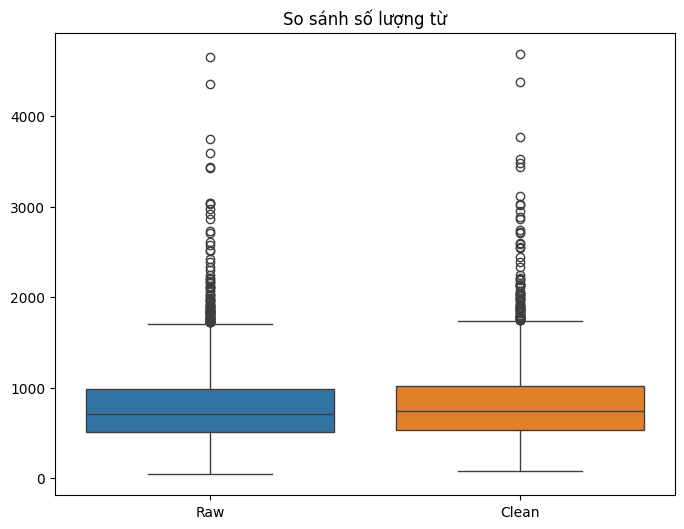

In [137]:
df_plot = pd.DataFrame({
    "Raw": economy_raw["Số lượng từ"],
    "Clean": economy_clean["Số lượng từ"]
})

plt.figure(figsize=(8,6))
sns.boxplot(data=df_plot)

plt.title("So sánh số lượng từ")
plt.show()

In [138]:
economy_clean.drop(columns=["text","topic_score"], inplace=True)

In [139]:
economy_clean.columns

Index(['index', 'URL', 'Tiêu đề', 'Nội dung', 'Từ khóa', 'Chuyên mục', 'Nguồn',
       'Số lượng từ', 'clean_text'],
      dtype='object')

## 3. Tokenize cho dữ liệu text
Sử dụng thư viện underthesea

In [140]:
from underthesea import word_tokenize

economy_clean["token_text"] = economy_clean.apply(
    lambda x: word_tokenize(x["clean_text"], format="text"),
    axis=1
)

## 4. Xây dựng và lựa chọn đặc trưng (feature engineering)
Cột "Từ khóa", "Số lượng từ" và "clean_text" và "token_text"

## 5. Trực quan hoá mối quan hệ đa biến

## 6. Kết luận

### 6.1 Về dữ liệu
Dữ liệu được crawl về khá sạch, sau khi trải qua giai đoạn tiền xử lý thì ...

### 6.2 Về tính khả thi

#### 6.2.1 Tính toán sentiment

##### 6.2.1.1 Phương pháp "Word count"

In [141]:
positive_words = set([
    "tăng","tốt","tích_cực","lợi_nhuận" "phát_triển",
    "growth","increase","positive","profit","improve"
])

negative_words = set([
    "giảm","xấu","tiêu_cực","lỗ","khủng_hoảng",
    "decrease","negative","loss","crisis","decline"
])

In [142]:
def lexicon_sentiment(text):
    tokens = text.split()

    pos_count = sum(1 for t in tokens if t in positive_words)
    neg_count = sum(1 for t in tokens if t in negative_words)

    if pos_count + neg_count == 0:
        return 0  # neutral

    score = (pos_count-neg_count) / (pos_count+neg_count)
    return score

In [143]:
economy_clean["lexicon_score"] = economy_clean["clean_text"].apply(lexicon_sentiment)

In [144]:
def map_label(score):
    if score > 0.1:
        return 1
    elif score < -0.1:
        return -1
    else:
        return 0

economy_clean["lexicon_score"] = economy_clean["lexicon_score"].apply(map_label)

##### 6.2.1.2 Phương pháp sử dụng model (PhoBERT)

In [145]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "wonrax/phobert-base-vietnamese-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

texts = economy_clean["clean_text"].tolist()

batch_size = 32
scores = []

for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]

    inputs = tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1)

    scores.extend((preds).cpu().numpy())

economy_clean["sentiment_score"] = scores

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/999 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

bpe.codes: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: wonrax/phobert-base-vietnamese-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

In [146]:
economy_clean["sentiment_score"].value_counts()

,count
sentiment_score,
0,893
1,842
2,763


In [147]:
mapping = {
    0.0 : -1,
    1.0 : 0,
    2.0 : 1
}

economy_clean["sentiment_score"] = economy_clean["sentiment_score"].map(mapping)

##### 6.2.1.3 So sánh

In [148]:
economy_clean["compare"] = (
    economy_clean["sentiment_score"] == economy_clean["lexicon_score"]
)

In [149]:
economy_clean["compare"].value_counts()

,count
compare,
False,1656
True,842


##### 6.2.1.4 Trực quan hóa

Text(0, 0.5, 'Frequency')

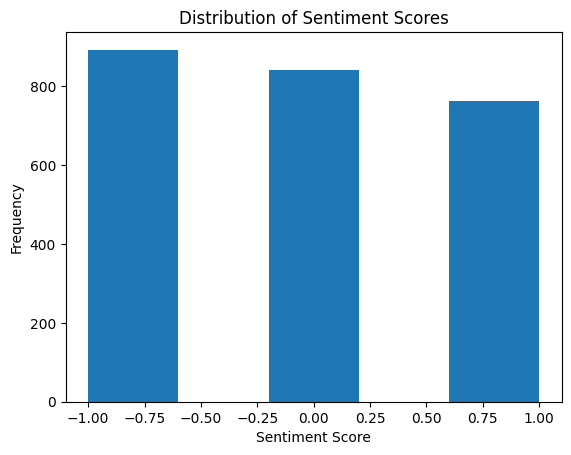

In [151]:
economy_clean["sentiment_score"].plot.hist(bins=5)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")

##### 6.2.1.5 Sentiment trung bình theo ngày

In [152]:
def extract_date(text, url):
    from_cafef = url[0:17]=="https://cafef.vn"
    # 1. lấy từ nội dung (Vietstock)
    match = re.search(r'(\d{2}:\d{2}\s\d{2}/\d{2}/\d{4})', str(text))
    if ~from_cafef and match:
        return match.group(1)

    # 2. fallback: lấy từ URL (CafeF)
    match_url = re.search(r'(\d{6})\d{9}\.chn', str(url))
    if from_cafef and match_url:
        d = match_url.group(1)
        return f"00:00 {d[4:6]}/{d[2:4]}/20{d[0:2]}"

    return None

economy_clean['Ngày đăng'] = economy_clean.apply(lambda x: extract_date(x['Nội dung'], x['URL']), axis=1)

/tmp/ipykernel_6175/1725795398.py:5: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  if ~from_cafef and match:


In [153]:
economy_clean["Ngày đăng"] = pd.to_datetime(
    economy_clean["Ngày đăng"],
    format="%H:%M %d/%m/%Y"
    )

daily_sentiment = economy_clean.groupby(
    economy_clean["Ngày đăng"].dt.date
)["sentiment_score"].mean().reset_index(name="avg_sentiment")

In [154]:
daily_sentiment

,Ngày đăng,avg_sentiment
0,2026-02-05,0.500000
1,2026-02-06,0.000000
2,2026-02-07,1.000000
3,2026-02-08,0.500000
4,2026-02-09,-0.500000
5,2026-02-10,0.714286
6,2026-02-11,-0.500000
7,2026-02-12,-1.000000
8,2026-02-13,-0.200000
9,2026-02-14,0.250000


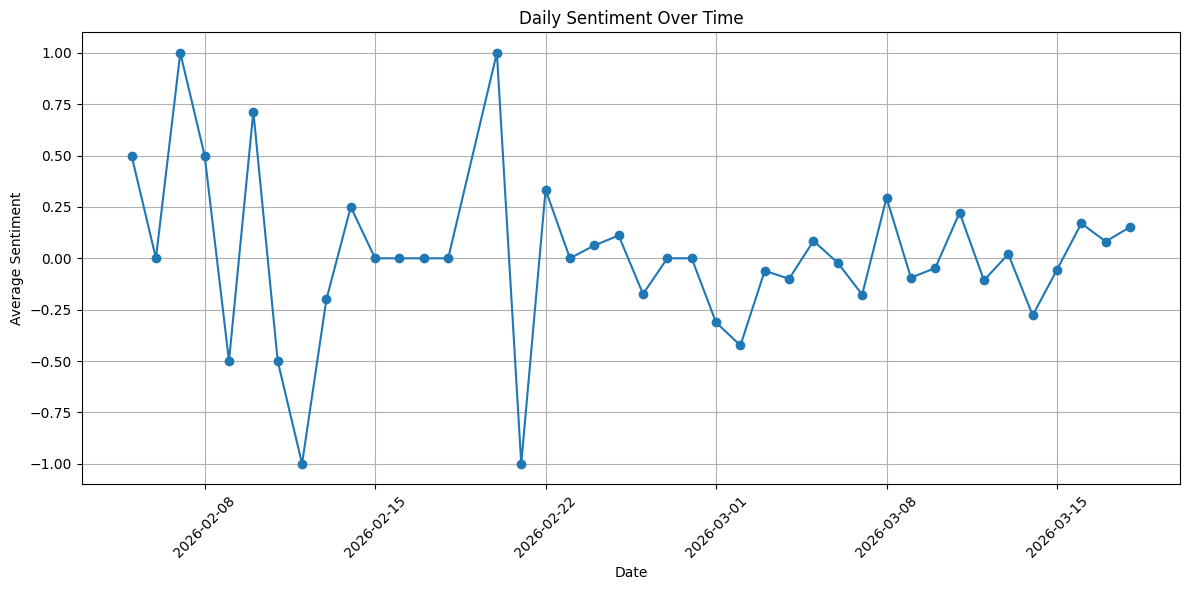

In [155]:
plt.figure(figsize=(12,6))
plt.plot(daily_sentiment["Ngày đăng"], daily_sentiment["avg_sentiment"], marker='o')

plt.title("Daily Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sentiment")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

#### 6.2.2 Vẽ WordCloud

##### 6.2.2.1 Loại bỏ stopwords

In [156]:
from nltk.corpus import stopwords

stop_words = {
    "và","là","của","có","cho","trong","một","những","được","với","các",
    "đã","này","đó","khi","đến","từ","ra","rằng","thì","vì","mà","nên",
    "như","để","sau","trước","vẫn","còn","cũng","lại","rất","hơn","ít",
    "nhiều","từng","tại","theo","qua","về","đi","lên","xuống","vào",
    "giữa","ngoài","trên","dưới","bên","cùng","cùng_với"
}
domain_stopwords = {
    "việt_nam","việt","nam",
    "theo","cho_biết","cho_rằng",
    "thông_tin","được_biết",
    "cơ_quan","bộ","ngành",
    "tỷ","triệu","tỷ_đồng",
    "năm","tháng","ngày"
}
stop_words = stop_words.union(domain_stopwords)

def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

economy_clean["token_text"] = economy_clean.apply(
    lambda x: remove_stopwords(x["token_text"]),
    axis=1
)

##### 6.2.2.2 WordCloud

In [157]:
all_text = " ".join(economy_clean["token_text"])

In [158]:
from google.colab import files
uploaded = files.upload()

Saving arial.ttf to arial.ttf


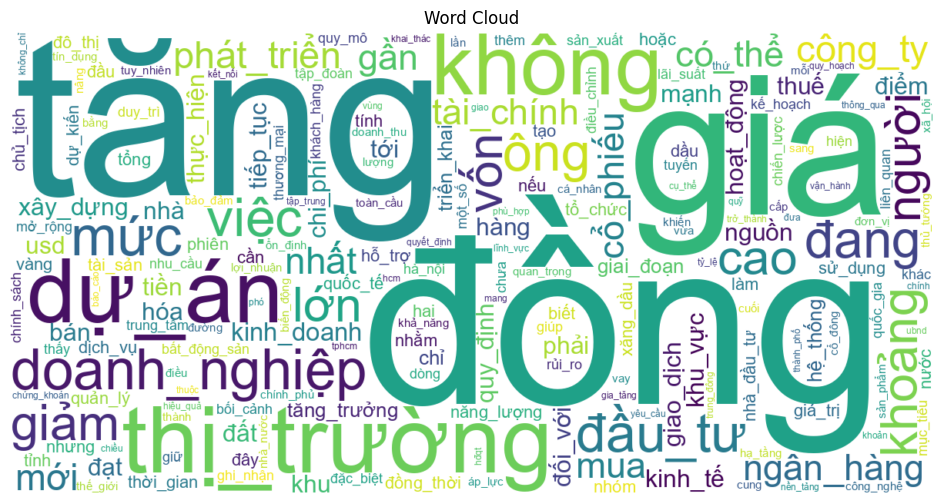

In [159]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    collocations=False,
    font_path="arial.ttf"
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [160]:
economy_clean.columns

Index(['index', 'URL', 'Tiêu đề', 'Nội dung', 'Từ khóa', 'Chuyên mục', 'Nguồn',
       'Số lượng từ', 'clean_text', 'token_text', 'lexicon_score',
       'sentiment_score', 'compare', 'Ngày đăng'],
      dtype='object')

In [161]:
cols_to_keep = ["URL","Tiêu đề","Nội dung","Từ khóa","Chuyên mục","Nguồn","clean_text"]

economy_clean[cols_to_keep].to_csv("clean_data.csv", index=False)
files.download("clean_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>